## -----------------------------------------------------------------------------
## INITIALIZATION
## -----------------------------------------------------------------------------
useful lines:

with_rx.printSchema()

train_df.select("ENROLID").distinct().count()

from pyspark.sql.functions import desc
df_adj.groupBy("SVCSCAT") \
      .count() \
      .orderBy(desc("count")) \
      .show(truncate=False)

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
import seaborn as sns
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/10 10:20:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/07/10 10:20:19 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/07/10 10:20:19 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
2025-07-10 10:20:20,409 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/07/10 10:20:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-07-10 10:20:22,031 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-07-10 10:20:23,395 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-07-10

## Calculate inflation factors to adjust yearly cost

In [8]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# a) compute average NETPAY per claim by calendar year
df_claims_rx = df_claims.filter(F.col("RX").isNotNull())
df_year = (df_claims_rx
    .groupBy("YEAR")
    .agg(F.avg("NETPAY").alias("avg_cost"))
)

# b) assemble & fit
assembler = VectorAssembler(inputCols=["YEAR"], outputCol="features")
df_lr = assembler.transform(df_year)

lr = LinearRegression(featuresCol="features", labelCol="avg_cost")
lr_model = lr.fit(df_lr)

slope = lr_model.coefficients[0]
intercept = lr_model.intercept

print(f"avg_cost ≈ {intercept:.2f} + {slope:.2f}·year")
def mk_inflation_map(years):
    base = intercept + slope * 2017.0
    return {int(y): float((intercept + slope * y) / base) for y in years}

inflation_map = mk_inflation_map([2017, 2018, 2019])
print(inflation_map)

25/07/10 10:40:35 WARN Instrumentation: [c86b4780] regParam is zero, which might cause numerical instability and overfitting.
25/07/10 10:40:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/07/10 10:40:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


avg_cost ≈ -26668.71 + 13.32·year
{2017: 1.0, 2018: 1.0685946832951803, 2019: 1.1371893665903605}


In [10]:
# broadcast your newly‐computed map
from pyspark.sql import functions as F
infl_map = sum([[F.lit(y), F.lit(f)] for y,f in inflation_map.items()], [])
inflation_expr = F.create_map(*infl_map)

df_adj = (df_claims_rx
    .withColumn("inflation_factor", inflation_expr[F.col("YEAR")])
    .withColumn("NETPAY17", F.col("NETPAY") / F.col("inflation_factor"))
    .drop("inflation_factor","NETPAY")
)



25/07/10 10:42:27 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not immediately visible in the filesystem.
25/07/10 10:42:33 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not immediately visible in the filesystem.
25/07/10 10:42:34 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not immediately visible in the filesystem.
25/07/10 10:42:38 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not immediately visible in the filesystem.
25/07/10 10:42:38 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not imme

In [49]:
df_adj.write.mode("overwrite").parquet("df_adj_inflation_withRX.parquet")


## Build features X by ENROLID

Use df_adj instead of df_claims (for NETPAY17).

Build pilot DataFrame that contains one year’s worth of claim‐level rows for your 1% enrollee sample—and build up the four pieces we need:

enrol_static: one row per (ENROLID, YEAR) with your demographic columns

agg_noncode: the non‐code numeric summaries (counts and flags) per (ENROLID, YEAR)

agg_cost: annual cost, ECDF rank, and high‐cost flag per (ENROLID, YEAR)

bag_of_codes: your pivoted “top‐N + OTHER” code counts per (ENROLID, YEAR)

Then we’ll join them all together on (ENROLID, YEAR).

### First define mini pilot cohort.

In [11]:
dx_cols = ['DX1', 'DX2', 'DX3', 'DX4', 'PDX']
df_enrollees_cols = ["AGEGRP","SEX","ENROLID","REGION","INDSTRY"]
#,"SVCDATE",
procedure_cols   = ["PROC1","PPROC","PROCGRP"] 
top_n       = 50
map_cols = ["SVCSCAT","STDPROV","STDPLAC","NTWKPROV","PAIDNTWK"]
claims_cols = procedure_cols+dx_cols+map_cols

25/07/10 10:42:48 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not immediately visible in the filesystem.
25/07/10 10:42:54 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not immediately visible in the filesystem.
25/07/10 10:42:55 WARN BasicWriteTaskStatsTracker: Expected 1 files, but only saw 0. This could be due to the output format not writing empty files, or files being not immediately visible in the filesystem.


In [13]:
cohort = (
  df_adj
    .select("ENROLID")
    .distinct()
    .sample(False, 0.01, seed=42)
)
pilot = (
  df_adj
    .join(cohort, "ENROLID", how="inner")
    .select( "YEAR",*df_enrollees_cols,*claims_cols)
)
pilot.write.mode("overwrite").parquet("pilot_inflation_withRX.parquet")


In [15]:
enrol_static = (
    pilot                       # or df_claims – anything that has YEAR
      .select(*df_enrollees_cols,
              "YEAR",            # ← now YEAR is present
              )
      .distinct()                # one row per enrollee-year
)

### Process non-bagged categoricals

In [35]:
from pyspark.sql import functions as F

# --- binary flags ---
pilot = (pilot
    .withColumn("NTWKPROV_flag", F.when(F.col("NTWKPROV") == "Y", 1).otherwise(0))
    .withColumn("PAIDNTWK_flag", F.when(F.col("PAIDNTWK") == "Y", 1).otherwise(0))
)

# --- STDPROV manual buckets ---
pilot = (pilot
    .withColumn("STDPROV_int", F.col("STDPROV").cast("int"))
    .withColumn(
        "stdprov_group",
        F.when((F.col("STDPROV_int").between(1,  99)), "Facility")
         .when((F.col("STDPROV_int").between(100,199)), "Non-admitting Phys")
         .when((F.col("STDPROV_int").between(200,499)), "Admitting Phys")
         .when((F.col("STDPROV_int").between(500,599)), "Surgeon")
         .when((F.col("STDPROV_int").between(600,799)), "Phys (other)")
         .when((F.col("STDPROV_int").between(800,899)), "Other Prof")
         .when((F.col("STDPROV_int").between(900,999)), "Agency")
         .otherwise("Unknown")
    )
)

# --- STDPLAC mapping ---
import json
with open("stdplac_group_map.json") as f:
    stdplac_map = json.load(f)

mapping_expr = F.create_map(*sum([[F.lit(k), F.lit(v)] for k, v in stdplac_map.items()], []))

pilot = pilot.withColumn(
    "STDPLAC_group",
    mapping_expr[F.col("STDPLAC").cast("string")]
)


In [44]:
pilot = pilot.drop("NTWKPROV", "PAIDNTWK", "STDPROV", "STDPLAC", "STDPROV_int")
# 1️⃣  First aggregate the raw counts you need
agg_noncode = (
    pilot
      .groupBy("ENROLID", "YEAR")
      .agg(
          F.sum("NTWKPROV_flag").alias("n_nw_claims"),
          F.sum("PAIDNTWK_flag").alias("n_paidnw_claims"),
          F.count("*").alias("total_claims"),

          # keep any other summaries you already added
          F.countDistinct("stdprov_group").alias("n_stdprov_groups"),
          F.countDistinct("STDPLAC_group").alias("n_stdplac_groups")
      )
)

# 2️⃣  Convert those counts into majority-of-claims indicators
agg_noncode = (
    agg_noncode
      .withColumn(
          "majority_nw_flag",
          F.when(F.col("n_nw_claims") >= 0.5 * F.col("total_claims"), 1).otherwise(0)
      )
      .withColumn(
          "majority_paidnw_flag",
          F.when(F.col("n_paidnw_claims") >= 0.5 * F.col("total_claims"), 1).otherwise(0)
      )
)

# 3️⃣  (optional) drop the intermediate counts if you no longer need them
agg_noncode = agg_noncode.drop("n_nw_claims", "n_paidnw_claims")



In [47]:
agg_noncode.show(5)

+-----------+----+------------+----------------+----------------+----------------+--------------------+
|    ENROLID|YEAR|total_claims|n_stdprov_groups|n_stdplac_groups|majority_nw_flag|majority_paidnw_flag|
+-----------+----+------------+----------------+----------------+----------------+--------------------+
|28468544305|2018|         121|               4|               5|               0|                   1|
| 3174619201|2018|         101|               4|               5|               1|                   1|
| 2459574501|2018|         167|               5|               3|               1|                   1|
| 4218919301|2019|          30|               2|               1|               1|                   1|
|33323882502|2019|         166|               6|               4|               1|                   1|
+-----------+----+------------+----------------+----------------+----------------+--------------------+
only showing top 5 rows


In [46]:
#agg_noncode.show()
agg_noncode.write.mode("overwrite").parquet("pilot_agg_noncode.parquet")


### Grouping into 1 DX column then select CKD stages then bag

Pull every diagnosis into one long column

In [19]:
from pyspark.sql import functions as F
from functools import reduce

dx_cols   = ["PDX","DX1","DX2","DX3","DX4"]      # whatever you have
keys      = ["ENROLID","YEAR"]

# explode all DX columns into a single long column `dx`
long_dx = reduce(
    lambda d, c: d.unionByName(
        pilot.select(*keys, F.col(c).alias("dx"))
    ),
    dx_cols,
    spark.createDataFrame([], schema="ENROLID string, YEAR int, dx string")
).filter("dx IS NOT NULL")


In [30]:
long_dx = long_dx.dropDuplicates(keys + ["dx"])
long_dx.show()

+---------------+----+-------+
|        ENROLID|YEAR|     dx|
+---------------+----+-------+
|   7.45646702E8|2019|  E1169|
|  2.844652501E9|2019|  I2510|
|  3.139617101E9|2018|   I214|
|  2.105553302E9|2018|  Z4823|
|  3.945947901E9|2018|  C7972|
|  3.063126101E9|2018|   I480|
|  3.424630303E9|2018|O321XX0|
|   7.00127801E8|2019|  G3183|
|3.2866192801E10|2018|   K921|
|3.3043859301E10|2018|   E875|
|  2.261740201E9|2018|  A4189|
|  3.948311801E9|2018|S272XXA|
|  3.360090601E9|2018|  E1010|
|  2.475979902E9|2018|T8131XA|
|  3.061428607E9|2018|  O1414|
|3.3052302001E10|2018|   I213|
|  3.332323202E9|2018|   C713|
|3.3082848402E10|2018|   N179|
|  3.063967401E9|2018|   C662|
|  2.106046901E9|2018|  M6088|
+---------------+----+-------+
only showing top 20 rows


In [31]:
from pyspark.sql import functions as F, Window

# ── 0) keep only CKD diagnoses and extract the stage ─────────────────────────
ckd_dx = (
    long_dx                     # ENROLID, YEAR, dx   (already exploded)
      .filter(F.col("dx").startswith("N18"))
      .withColumn(
          "stage",
          F.when(F.col("dx").rlike(r"N18[1-6]"),
                 F.col("dx").substr(4, 1).cast("int"))
           .when(F.col("dx") == "N189", F.lit(0))     # unspecified CKD
      )
      .filter(F.col("stage").isNotNull())             # drop weird values
)

ckd_dx.show()

+---------------+----+----+-----+
|        ENROLID|YEAR|  dx|stage|
+---------------+----+----+-----+
|  3.650736402E9|2018|N186|    6|
|  2.664112503E9|2018|N186|    6|
|  3.149804101E9|2019|N186|    6|
|  3.358787402E9|2019|N186|    6|
|  3.171034401E9|2018|N182|    2|
|  3.136430503E9|2018|N183|    3|
|3.2863607601E10|2018|N185|    5|
|3.3013012402E10|2018|N182|    2|
|  3.199281201E9|2018|N184|    4|
|  1.963949502E9|2018|N189|    0|
|3.3013012402E10|2018|N189|    0|
|   7.00127801E8|2019|N183|    3|
|3.2863607601E10|2018|N183|    3|
|  4.218557501E9|2019|N185|    5|
|3.2863607601E10|2018|N189|    0|
|  3.246101401E9|2019|N181|    1|
|   6.20923901E8|2019|N189|    0|
|3.2441794001E10|2018|N189|    0|
|  3.020710802E9|2018|N185|    5|
|  1.270960501E9|2019|N189|    0|
+---------------+----+----+-----+
only showing top 20 rows


In [32]:
# ── 1) simple per-member per-year aggregates ────────────────────────────────
ckd_basic = (
    ckd_dx.groupBy("ENROLID", "YEAR")
          .agg(
              F.count("*").alias("ckd_dx_cnt"),
              F.max("stage").alias("ckd_stage_max")
          )
)
# ── 2) modal stage (most frequent; ties → highest stage)  ───────────────────
stage_freq = (
    ckd_dx.groupBy("ENROLID", "YEAR", "stage")
           .count()
)

w = (
    Window.partitionBy("ENROLID", "YEAR")
          .orderBy(F.desc("count"), F.desc("stage"))   # tie-break ↑
)

stage_mode = (
    stage_freq.withColumn("rn", F.row_number().over(w))
              .filter("rn = 1")
              .select("ENROLID", "YEAR",
                      F.col("stage").alias("ckd_stage_mode"))
)
# ── 3) final CKD stats table ────────────────────────────────────────────────
ckd_stats = (
    ckd_basic.join(stage_mode, ["ENROLID", "YEAR"], "left")
             .fillna({"ckd_stage_mode": 0})            # if only N189
             .withColumn("has_ckd",
                         F.when(F.col("ckd_dx_cnt") > 0, 1).otherwise(0))
)

ckd_stats.show(truncate=False)

+---------------+----+----------+-------------+--------------+-------+
|ENROLID        |YEAR|ckd_dx_cnt|ckd_stage_max|ckd_stage_mode|has_ckd|
+---------------+----+----------+-------------+--------------+-------+
|3.427768302E9  |2019|1         |3            |3             |1      |
|2.808027002E9  |2019|3         |3            |3             |1      |
|1.050584201E9  |2019|2         |3            |3             |1      |
|4.014777401E9  |2018|1         |3            |3             |1      |
|2.6964894101E10|2019|1         |3            |3             |1      |
|6.09688901E8   |2019|2         |2            |2             |1      |
|3.3326253601E10|2017|1         |3            |3             |1      |
|4.115673403E9  |2019|1         |0            |0             |1      |
|3.171089402E9  |2018|1         |2            |2             |1      |
|1.262021102E9  |2017|2         |3            |3             |1      |
|4.222498601E9  |2018|1         |3            |3             |1      |
|2.228

In [38]:
from pyspark.sql import functions as F

mixed = (
    ckd_dx.groupBy("ENROLID", "YEAR")
          .agg(F.countDistinct("stage").alias("distinct_stages"))
          .filter("distinct_stages > 1")
)

print("Enrollee-years with >1 CKD stage:", mixed.count())
mixed.show(5, truncate=False)


Enrollee-years with >1 CKD stage: 906


+-------------+----+---------------+
|ENROLID      |YEAR|distinct_stages|
+-------------+----+---------------+
|2.808027002E9|2019|3              |
|1.050584201E9|2019|2              |
|6.09688901E8 |2019|2              |
|1.262021102E9|2017|2              |
|3.08011502E8 |2018|3              |
+-------------+----+---------------+
only showing top 5 rows


In [40]:
long_dx = long_dx.withColumn("dx_grp", F.substring("dx", 1, 3))
code_col = "dx_grp"          # use this in the next step
# If you prefer the full 3-5 character codes, set code_col = "dx"
long_dx.select("dx_grp").distinct().show()
TOP_N = 50                                   # tweak if you like

top_vals = (
    long_dx.groupBy(code_col)
           .count()
           .orderBy(F.desc("count"))
           .limit(TOP_N)
           .select(code_col)
           .rdd.flatMap(lambda r: r)
           .collect()
)

long_dx = long_dx.withColumn(
    "dx_bkt",
    F.when(F.col(code_col).isin(top_vals), F.col(code_col))
     .otherwise(F.lit("OTHER"))
)


+------+
|dx_grp|
+------+
|   M19|
|   I31|
|   F25|
|   F32|
|   M54|
|   K56|
|   O14|
|   C78|
|   M46|
|   I21|
|   O11|
|   C77|
|   J93|
|   Q62|
|   I63|
|   N99|
|   E66|
|   O34|
|   I61|
|   K80|
+------+
only showing top 20 rows


In [42]:
bag_dx = (
    long_dx
      .groupBy(*keys)
      .pivot("dx_bkt")
      .count()
      .na.fill(0)                # absent codes ⇒ 0
)


### “Bag-of-codes” vectors for DX columns without aggregating into 1 DX column nor grouping into chapters (first 3 chars)

In [ ]:
# 3) For each code column, find its top N and bucket the rest as “OTHER”
def bucket_topN(df, col, N=top_n):
    top_vals = (
        df.groupBy(col)
          .count()
          .orderBy(F.desc("count"))
          .limit(N)
          .select(col)
          .rdd.flatMap(lambda row: row)
          .collect()
    )
    return df.withColumn(
        f"{col}_bkt",
        F.when(F.col(col).isin(top_vals), F.col(col))
         .otherwise(F.lit("OTHER"))
    )

for c in code_cols:
    pilot = bucket_topN(pilot, c)



In [ ]:
# 4) Pivot each “_bkt” column into its own wide count table, then join them all back together
keys = ["ENROLID","YEAR"]
pivoted_tables = []
for c in dx_cols:
    pivoted = (
      pilot
        .groupBy(*keys)
        .pivot(f"{c}_bkt")
        .count()
        .na.fill(0)
    )
    pivoted_tables.append(pivoted)

# start from the first pivot
bag_of_codes = reduce(
    lambda df1, df2: df1.join(df2, on=keys, how="inner"),
    pivoted_tables
)

# 5) Now bag_of_codes has one column per “<CODE>_VALUE” with counts
bag_of_codes.printSchema()
bag_of_codes.show(5, truncate=False)


root
 |-- ENROLID: decimal(38,0) (nullable = true)
 |-- YEAR: decimal(38,0) (nullable = true)
 |-- 01: long (nullable = true)
 |-- 02: long (nullable = true)
 |-- 03: long (nullable = true)
 |-- 04: long (nullable = true)
 |-- 05: long (nullable = true)
 |-- 06: long (nullable = true)
 |-- 07: long (nullable = true)
 |-- 09: long (nullable = true)
 |-- 30: long (nullable = true)
 |-- 50: long (nullable = true)
 |-- 51: long (nullable = true)
 |-- 61: long (nullable = true)
 |-- 62: long (nullable = true)
 |-- 63: long (nullable = true)
 |-- 64: long (nullable = true)
 |-- 65: long (nullable = true)
 |-- 66: long (nullable = true)
 |-- 70: long (nullable = true)
 |-- 81: long (nullable = true)
 |-- 83: long (nullable = true)
 |-- 84: long (nullable = true)
 |-- 94: long (nullable = true)
 |-- 98: long (nullable = true)
 |-- 99: long (nullable = true)
 |-- OTHER: long (nullable = true)
 |-- 1: long (nullable = true)
 |-- 2: long (nullable = true)
 |-- 3: long (nullable = true)
 |-- 4: lo

+--------+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+-----+----+----+----+-----+----+-----+-----+----+----+----+----+----+----+-----+---+-----+-----+------+------+------+-----+----+----+-----+----+----+----+----+----+----+----+-----+---+-----+-----+----+----+-----+---+-----+-----+-----+------+------+-----+-----+---+-----+------+----+----+----+---+----+----+------+----+-----+----+-----+-----+-----+-----+-----+----+----+----+-----+----+-----+----+----+----+----+----+------+----+----+-----+-----+---+----+-----+----+------+----+----+-----+----+----+----+-----+----+-----+---+----+---+----+------+----+----+----+----+----+-----+-----+----+----+-----+----+-----+----+----+----+----+----+----+------+----+----+-----+---+----+-----+------+----+----+----+----+-----+------+-----+-----+-----+----+----+----+-----+----+-----+---+----+----+-----+-----+----+---+----+------+----+-----+----+----+-----+----+-----+----+----+-

In [33]:
# 3) For each code column, find its top N and bucket the rest as “OTHER”
def bucket_topN(df, col, N=top_n):
    top_vals = (
        df.groupBy(col)
          .count()
          .orderBy(F.desc("count"))
          .limit(N)
          .select(col)
          .rdd.flatMap(lambda row: row)
          .collect()
    )
    return df.withColumn(
        f"{col}_bkt",
        F.when(F.col(col).isin(top_vals), F.col(col))
         .otherwise(F.lit("OTHER"))
    )

for c in code_cols:
    pilot = bucket_topN(pilot, c)



In [34]:
# 4) Pivot each “_bkt” column into its own wide count table, then join them all back together
keys = ["ENROLID","YEAR"]
pivoted_tables = []
for c in code_cols:
    pivoted = (
      pilot
        .groupBy(*keys)
        .pivot(f"{c}_bkt")
        .count()
        .na.fill(0)
    )
    pivoted_tables.append(pivoted)

# start from the first pivot
bag_of_codes = reduce(
    lambda df1, df2: df1.join(df2, on=keys, how="inner"),
    pivoted_tables
)

# 5) Now bag_of_codes has one column per “<CODE>_VALUE” with counts
bag_of_codes.printSchema()
bag_of_codes.show(5, truncate=False)


root
 |-- ENROLID: decimal(38,0) (nullable = true)
 |-- YEAR: decimal(38,0) (nullable = true)
 |-- 01: long (nullable = true)
 |-- 02: long (nullable = true)
 |-- 03: long (nullable = true)
 |-- 04: long (nullable = true)
 |-- 05: long (nullable = true)
 |-- 06: long (nullable = true)
 |-- 07: long (nullable = true)
 |-- 09: long (nullable = true)
 |-- 30: long (nullable = true)
 |-- 50: long (nullable = true)
 |-- 51: long (nullable = true)
 |-- 61: long (nullable = true)
 |-- 62: long (nullable = true)
 |-- 63: long (nullable = true)
 |-- 64: long (nullable = true)
 |-- 65: long (nullable = true)
 |-- 66: long (nullable = true)
 |-- 70: long (nullable = true)
 |-- 81: long (nullable = true)
 |-- 83: long (nullable = true)
 |-- 84: long (nullable = true)
 |-- 94: long (nullable = true)
 |-- 98: long (nullable = true)
 |-- 99: long (nullable = true)
 |-- OTHER: long (nullable = true)
 |-- 1: long (nullable = true)
 |-- 2: long (nullable = true)
 |-- 3: long (nullable = true)
 |-- 4: lo

+--------+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+-----+----+----+----+-----+----+-----+-----+----+----+----+----+----+----+-----+---+-----+-----+------+------+------+-----+----+----+-----+----+----+----+----+----+----+----+-----+---+-----+-----+----+----+-----+---+-----+-----+-----+------+------+-----+-----+---+-----+------+----+----+----+---+----+----+------+----+-----+----+-----+-----+-----+-----+-----+----+----+----+-----+----+-----+----+----+----+----+----+------+----+----+-----+-----+---+----+-----+----+------+----+----+-----+----+----+----+-----+----+-----+---+----+---+----+------+----+----+----+----+----+-----+-----+----+----+-----+----+-----+----+----+----+----+----+----+------+----+----+-----+---+----+-----+------+----+----+----+----+-----+------+-----+-----+-----+----+----+----+-----+----+-----+---+----+----+-----+-----+----+---+----+------+----+-----+----+----+-----+----+-----+----+----+-

### Create 2 new features: claims count and ECDF ranking of total annual cost by region.

In [34]:

agg_cost = (
    df_adj
      .groupBy("ENROLID", "REGION",  "YEAR")
      .agg(
        F.sum("NETPAY17").alias("annual_cost17"),
        F.count("*").alias("utilization_count")
      )
)

# 75th-pct flag on the ECDF target:
# 1) Define an ECDF window over REGION and YEAR
w = Window.partitionBy("REGION", "YEAR").orderBy("annual_cost17")

# 2) Compute the ECDF and flag the top 25%
agg_cost = (
    agg_cost
      .withColumn("cost_ecdf", F.cume_dist().over(w))
      .withColumn("high_cost", F.when(F.col("cost_ecdf") >= 0.75, 1).otherwise(0))
)

agg_cost.show(10)

+----------+------+----+-------------------+-----------------+--------------------+---------+
|   ENROLID|REGION|YEAR|      annual_cost17|utilization_count|           cost_ecdf|high_cost|
+----------+------+----+-------------------+-----------------+--------------------+---------+
|2311037602|     4|2019|-54721.721665918616|              818|9.281776160686108E-6|        0|
|2311395602|     4|2019| -53457.30604417348|              787|1.856355232137221...|        0|
|3481805601|     4|2019|-16201.514489395351|              161|2.784532848205832...|        0|
|4267907601|     4|2019|   -5542.4542166603|               15|3.712710464274443E-5|        0|
|2309175501|     4|2019| -2501.052228906859|               40|4.640888080343054...|        0|
|2312476102|     4|2019| -611.7011119139111|                7|5.569065696411665...|        0|
|2833057401|     4|2019|-479.79695909040606|               20|6.497243312480276E-5|        0|
|4150685701|     4|2019|-145.05060005491455|               1

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_1238/1899525950.py:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


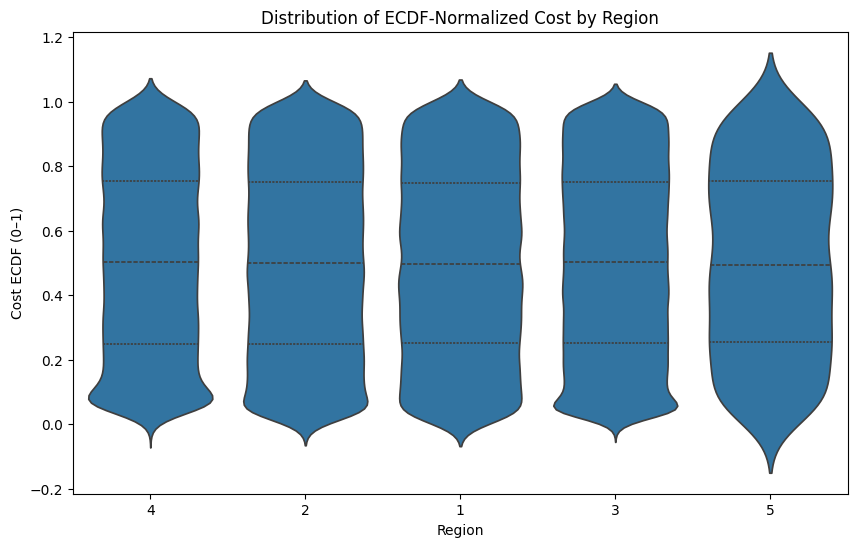

In [11]:
# 1) (Optionally) take a sample so you don't OOM when converting:
spark_sample = agg_cost.sample(False, 0.1, seed=42)  

# 2) Convert to pandas:
df_ranked_pd = spark_sample.toPandas()
plt.figure(figsize=(10,6))
sns.violinplot(
    x="REGION",
    y="cost_ecdf",
    data=df_ranked_pd,
    inner="quartile",   # shows median & IQR
    scale="width",      # all violins have same maximum width
)
plt.title("Distribution of ECDF-Normalized Cost by Region")
plt.xlabel("Region")
plt.ylabel("Cost ECDF (0–1)")
plt.show()


### Join everything into one “enrollee × year” table


In [39]:
df_final = (enrol_static
    .join(agg_noncode,  ["ENROLID", "YEAR"], "left")
    .join(bag_of_codes, ["ENROLID", "YEAR"], "left")
    .join(agg_cost,     ["ENROLID", "YEAR"], "left")
    .join(ckd_stats,    ["ENROLID", "YEAR"], "left"))

df_final.show(2)
print("Unique enrollees: ",df_final.select("ENROLID").distinct().count())

+---------+----+------+---+------+-------+--------------+-------------+------------+----------------+----------------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+----+----+----+----+----+-----+----+----+----+-----+----+-----+-----+----+----+----+----+----+----+-----+----+-----+-----+------+------+------+-----+----+----+-----+----+----+----+----+----+----+----+-----+----+-----+-----+----+----+-----+----+-----+-----+-----+------+------+-----+-----+----+-----+------+----+----+----+----+----+----+------+----+-----+----+-----+-----+-----+-----+-----+----+----+----+-----+----+-----+----+----+----+----+----+------+----+----+-----+-----+----+----+-----+----+------+----+----+-----+----+----+----+-----+----+-----+----+----+----+----+------+----+----+----+----+----+-----+-----+----+----+-----+----+-----+----+----+----+----+----+----+------+----+----+-----+----+----+-----+------+----+----+----+----+-----+------+-----

Unique enrollees:  862310


In [42]:
from collections import defaultdict

dupe_counter = defaultdict(int)
safe_names   = []

for c in df_final.columns:
    dupe_counter[c] += 1
    # first time we see the name → keep it as-is
    if dupe_counter[c] == 1:
        safe_names.append(c)
    else:             # 2nd, 3rd… time → give it a suffix
        safe_names.append(f"{c}_{dupe_counter[c]}")

df_final_safe = df_final.toDF(*safe_names)

# now this will succeed
df_final_safe.write.mode("overwrite").parquet("pilot_bag_codes_joined.parquet")


25/07/09 18:39:07 WARN DAGScheduler: Broadcasting large task binary with size 1180.7 KiB


## Model pipeline

In [3]:
df_final = spark.read.format("parquet").load( "pilot_bag_codes_joined.parquet")

+-----------+----+------+---+------+-------+--------------+-------------+------------+----------------+----------------+------+------------------+-----------------+------------------+---------+----------+-------------+--------------+-------+
|    ENROLID|YEAR|AGEGRP|SEX|REGION|INDSTRY|claims_nw_flag|claims_paidnw|total_claims|n_stdprov_groups|n_stdplac_groups|REGION|     annual_cost17|utilization_count|         cost_ecdf|high_cost|ckd_dx_cnt|ckd_stage_max|ckd_stage_mode|has_ckd|
+-----------+----+------+---+------+-------+--------------+-------------+------------+----------------+----------------+------+------------------+-----------------+------------------+---------+----------+-------------+--------------+-------+
|31790427602|2018|     5|  1|     3|      7|            65|           96|          96|               4|               4|     3| 17673.73569720734|               96|0.8528139048200268|        1|      NULL|         NULL|          NULL|   NULL|
|  700127801|2019|     5|  1|   

Unique enrollees:  8689


### Build your train/test sets

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
label_col    = "high_cost"                     # ❶ target
key_cols     = ["ENROLID", "YEAR"]             # keep for splitting, drop later

# any column that is *numeric* and *not* a meta column is fair game ----------
numeric_feats = [
    f.name for f in df_final.schema.fields
    if (f.name not in key_cols + [label_col])
       and not f.name.endswith("_idx")         # we already used OHE counts
       and f.dataType.simpleString() in ("double", "int", "bigint", "float")
]

print(f"{len(numeric_feats)} numeric feature columns")


In [19]:
# keep only rows that have the label present
df_mod = df_final.where(F.col(label_col).isNotNull())

train_raw = df_mod.filter("YEAR in (2017, 2018)")
test_raw  = df_mod.filter("YEAR = 2019")

# ── tiny pilot (10 %) so the first fit runs quickly ────────────────
train_ids_sample = (
    train_raw.select("ENROLID").distinct()
             .sample(False, 0.10, seed=42)     # ← raise to 1.0 later
)

train = train_raw.join(train_ids_sample, "ENROLID")
test  = test_raw                              # full 2019

print("Train rows:", train.count(), "  Test rows:", test.count())


Pilot size: 1630845


Train rows: 1303049, Test rows: 327796


Test RMSE: 1.1201648440141294
Test R2:   0.0999540512884709


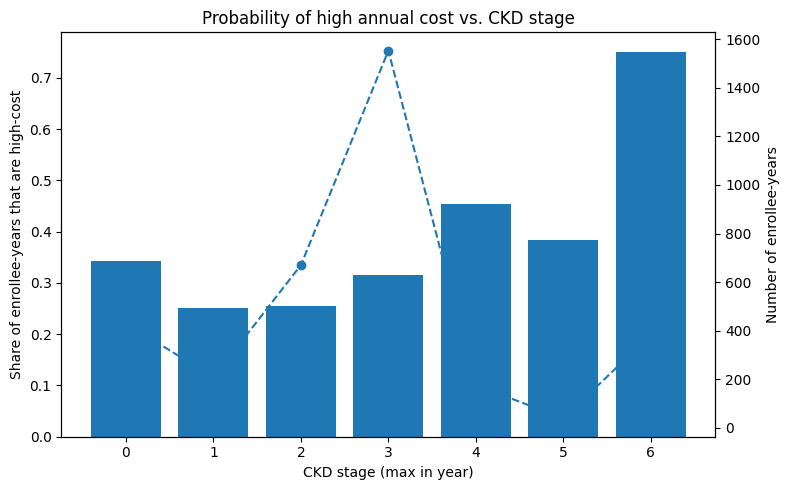

In [43]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

# 1️⃣  Spark-side aggregation
df_ckd = (
    df_final
      .filter(F.col("has_ckd") == 1)            # only rows with CKD diagnoses
      .groupBy("ckd_stage_max")                 # ← use stage _max_ per enrollee-year
      .agg(
          F.count("*").alias("n_total"),
          F.sum("high_cost").alias("n_high")
      )
      .withColumn("pct_high", F.col("n_high") / F.col("n_total"))
      .orderBy("ckd_stage_max")
)

# 2️⃣  Pull the small result to the driver for plotting
ckd_pd = df_ckd.toPandas()

# 3️⃣  Matplotlib: bar = % high-cost ; dashed line = cohort size
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(ckd_pd["ckd_stage_max"], ckd_pd["pct_high"])
ax1.set_xlabel("CKD stage (max in year)")
ax1.set_ylabel("Share of enrollee-years that are high-cost")
ax1.set_title("Probability of high annual cost vs. CKD stage")

# optional – raw counts on a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(ckd_pd["ckd_stage_max"], ckd_pd["n_total"],
         marker="o", linestyle="--")
ax2.set_ylabel("Number of enrollee-years")

fig.tight_layout()
plt.show()


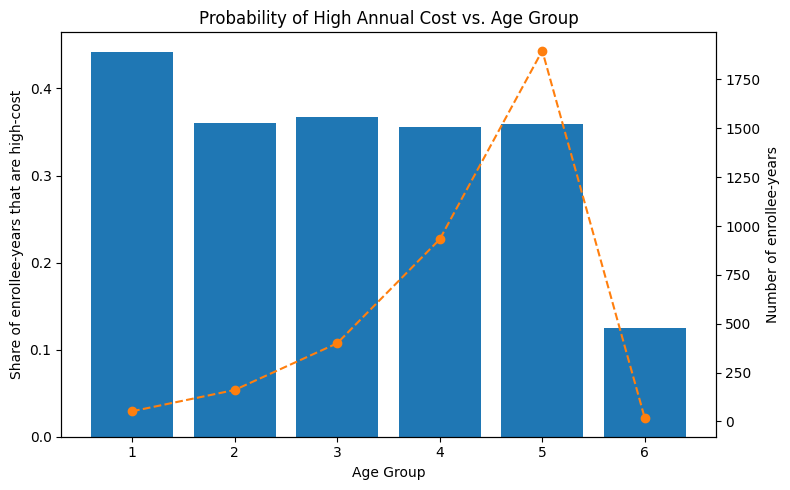

In [48]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

# 1️⃣  Spark‐side aggregation by age group
df_age = (
    df_final
      .filter(F.col("has_ckd") == 1)        # only rows with CKD diagnoses
      .groupBy("AGEGRP")                    # ← now grouping by age group
      .agg(
          F.count("*").alias("n_total"),
          F.sum("high_cost").alias("n_high")
      )
      .withColumn("pct_high", F.col("n_high") / F.col("n_total"))
      .orderBy("AGEGRP")
)

# 2️⃣  Pull to pandas
age_pd = df_age.toPandas()

# 3️⃣  Plot
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(age_pd["AGEGRP"].astype(str), age_pd["pct_high"])
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Share of enrollee-years that are high-cost")
ax1.set_title("Probability of High Annual Cost vs. Age Group")

# optional – add raw counts on secondary axis
ax2 = ax1.twinx()
ax2.plot(age_pd["AGEGRP"].astype(str), age_pd["n_total"],
         marker="o", linestyle="--", color="C1")
ax2.set_ylabel("Number of enrollee-years")

fig.tight_layout()
plt.show()
